---

# LESSON 16: ASSIGNMENT - CHART FORMATTING

---

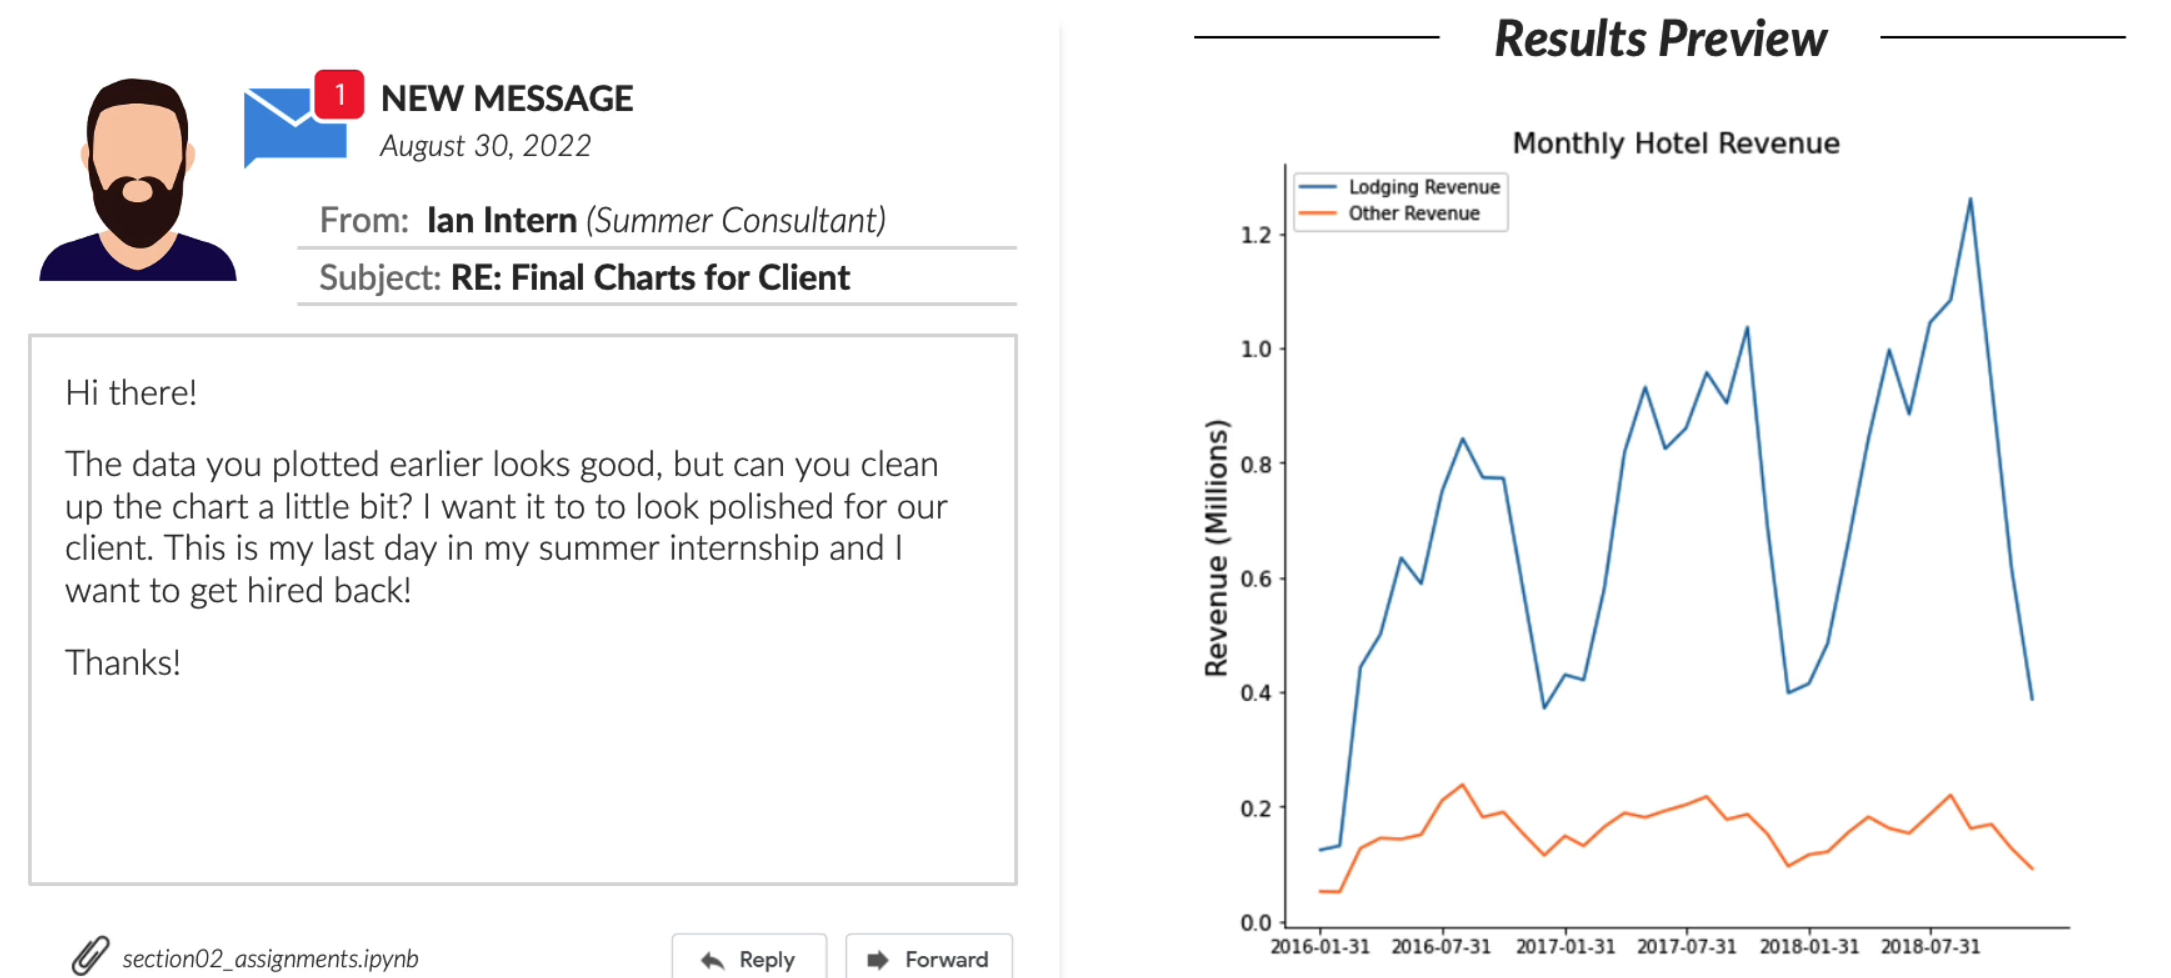

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
hotels = pd.read_excel('../Data/HotelCustomersDataset.xlsx')

hotels['date'] = (pd
    .to_datetime('2018-12-31') - pd.to_timedelta(hotels['DaysSinceCreation'], unit='D')).astype('datetime64[ns]')

hotels

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,...,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom,date
0,1,PRT,51.0,150,45,371.0,105.3,1,0,3,...,0,0,0,0,0,0,0,0,0,2018-08-03
1,2,PRT,NaN,1095,61,280.0,53.0,0,0,1,...,0,0,0,0,0,0,0,0,0,2016-01-01
2,3,DEU,31.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,2016-01-01
3,4,FRA,60.0,1095,93,240.0,60.0,0,0,1,...,0,0,0,0,0,0,0,0,0,2016-01-01
4,5,FRA,51.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,2016-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83585,83586,ITA,54.0,0,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,2018-12-31
83586,83587,IRL,47.0,0,109,327.1,277.5,0,0,1,...,0,0,0,1,0,0,0,0,0,2018-12-31
83587,83588,IRL,53.0,0,0,0.0,0.0,0,0,0,...,0,0,0,1,0,0,0,0,0,2018-12-31
83588,83589,IRL,85.0,0,109,981.3,9.0,0,0,1,...,0,0,0,0,1,0,0,0,0,2018-12-31


In [10]:
df = hotels[['date', 'LodgingRevenue', 'OtherRevenue']]
df = df.set_index('date')
df = df.resample('ME').sum()

display(df.head(3), df.tail(3))

,LodgingRevenue,OtherRevenue
date,,
2016-01-31,124531.34,52190.50
2016-02-29,131689.12,51203.13
2016-03-31,443476.86,127336.11


,LodgingRevenue,OtherRevenue
date,,
2018-10-31,937981.88,169456.07
2018-11-30,615718.87,127023.95
2018-12-31,387189.77,91732.71


<br><br>

---

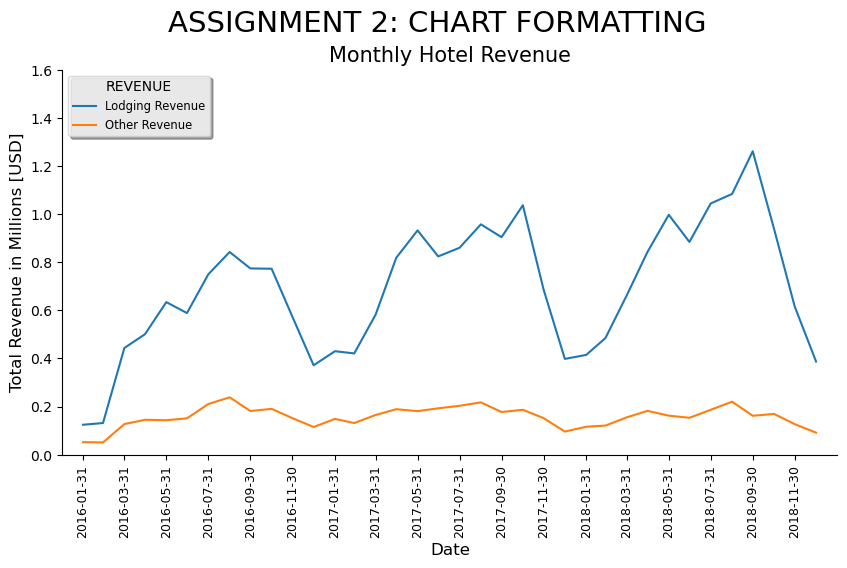

In [31]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df/1e6)

fig.suptitle('ASSIGNMENT 2: CHART FORMATTING', fontsize=21, y=1)
ax.set_title('Monthly Hotel Revenue', fontsize=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Revenue in Millions [USD]', fontsize=12)

ax.set_xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2019-01-31'))
ax.set_ylim(0, 1.6)

ax.set_xticks(df.index[::2])
plt.xticks(rotation=90, fontsize=9)

ax.legend(['Lodging Revenue', 'Other Revenue'], 
          loc='upper left',
          shadow=True, 
          fancybox=True,
          framealpha=0.75,
          title='REVENUE',
          title_fontsize='medium',
          fontsize='small'
         )

ax.spines[['top', 'right']].set_visible(False)

plt.show()